In [1]:
# Notebook to define and evaluate a Siamese UNet with a custom weighting schema 

In [2]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("CWD:", os.getcwd())
print("Project root added:", project_root)

CWD: c:\Dev\Damage_Assessment_on_xBD\Model_Architectures Notebooks
Project root added: c:\Dev\Damage_Assessment_on_xBD


In [3]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from  src.model_siamese import SiameseUNet
from torch.amp import GradScaler

scaler = GradScaler('cuda')

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4070


In [5]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 4
LR = 1e-4
NUM_EPOCHS = 50
PATIENCE = 15
BASE_FEATURES = 24
SAVE_PATH = "best_siamese_unet_combo.pth"

In [6]:
# Create Data Splits
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from Preprocessing.xBD_splits import create_splits
img_dir = r"..\Preprocessing\tiles\images"
mask_dir = r"..\Preprocessing\tiles\masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 9820
Val: 1960
Test: 1912
Train: 9820  Val: 1960  Test: 1912


In [7]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, num_workers = 4, pin_memory = True, siamese=True, augment_train=True)

In [8]:
# Sanity check
pre, post, masks = next(iter(train_loader))

print(f"Pre image:  {pre.shape}")    # [B, 3, H, W]
print(f"Post image: {post.shape}")   # [B, 3, H, W]
print(f"Masks:      {masks.shape}")  # [B, H, W]
print(f"Mask range: {masks.min()} – {masks.max()}")
print(f"Device:     {pre.device}")

Pre image:  torch.Size([4, 3, 512, 512])
Post image: torch.Size([4, 3, 512, 512])
Masks:      torch.Size([4, 512, 512])
Mask range: 0 – 4
Device:     cpu


In [9]:
# Loss — ComboLoss (CE + Tversky)
"""class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

freqs = class_counts / class_counts.sum()
weights = 1.0 / torch.sqrt(freqs)
weights = weights / weights.mean()
class_weights = weights.to(device)
"""
class_weights = torch.tensor([0.5, 2.0, 20.0, 18.0, 4.0], dtype=torch.float32).to(device)

In [10]:
# Model
model = SiameseUNet(
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES,
    in_channels=3 # only include 3 channels for Siamese
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(next(model.parameters()).device)

Model parameters: 5,839,277
cuda:0


In [11]:
# Loss, Optimizer, LR Scheduler (Define Here)
criterion = ComboLoss(class_weights=class_weights,
                      ce_weight=0.3,
                      tversky_weight=0.7, tversky_alpha=0.85, tversky_beta=0.15, tversky_gamma=0.6,
                      num_classes=NUM_CLASSES).to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay = 1e-4)

#scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=2e-4, steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS, pct_start=0.1, div_factor=10, final_div_factor=100)

In [12]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True,
    siamese = True, scaler=scaler)



Epoch 1/50  (lr=2.00e-05)
  Train Loss: 1.0673  |  Val Loss: 0.9994
  Train mIoU: 0.2008  |  Val mIoU: 0.2162
  Train Acc:  0.7504  |  Val Acc:  0.8585
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.8609   0.9936   0.8657
    Minor             0.2165   0.2335   0.7480
    Major             0.0011   0.0011   0.2074
    Destroyed         0.0026   0.0042   0.0065
    Unclassified      0.0000   0.0399   0.0000
  *** Saved new best model (mIoU=0.2162) ***



Epoch 2/50  (lr=3.72e-05)
  Train Loss: 0.9148  |  Val Loss: 0.8255
  Train mIoU: 0.2873  |  Val mIoU: 0.2921
  Train Acc:  0.8862  |  Val Acc:  0.9345
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9426   0.9871   0.9544
    Minor             0.3116   0.4159   0.5540
    Major             0.0013   0.0013   0.1488
    Destroyed         0.0071   0.0072   0.2537
    Unclassified      0.1978   0.4447   0.2627
  *** Saved new best model (mIoU=0.2921) ***



Epoch 3/50  (lr=8.22e-05)
  Train Loss: 0.8160  |  Val Loss: 0.8013
  Train mIoU: 0.3449  |  Val mIoU: 0.2586
  Train Acc:  0.9064  |  Val Acc:  0.9202
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9352   0.9893   0.9447
    Minor             0.2692   0.4019   0.4492
    Major             0.0019   0.0019   0.5481
    Destroyed         0.0075   0.0076   0.3037
    Unclassified      0.0793   0.3597   0.0923



Epoch 4/50  (lr=1.38e-04)
  Train Loss: 0.7817  |  Val Loss: 0.8038
  Train mIoU: 0.3638  |  Val mIoU: 0.2347
  Train Acc:  0.9147  |  Val Acc:  0.8837
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.8866   0.9942   0.8913
    Minor             0.2742   0.2993   0.7664
    Major             0.0014   0.0015   0.2748
    Destroyed         0.0070   0.0071   0.3637
    Unclassified      0.0041   0.0308   0.0047



Epoch 5/50  (lr=1.83e-04)
  Train Loss: 0.7621  |  Val Loss: 0.7516
  Train mIoU: 0.3861  |  Val mIoU: 0.3274
  Train Acc:  0.9211  |  Val Acc:  0.9415
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9450   0.9922   0.9520
    Minor             0.4038   0.4661   0.7512
    Major             0.0020   0.0020   0.1391
    Destroyed         0.0154   0.0158   0.3897
    Unclassified      0.2708   0.5064   0.3679
  *** Saved new best model (mIoU=0.3274) ***


...


Epoch 46/50  (lr=6.22e-06)
  Train Loss: 0.6206  |  Val Loss: 0.7195
  Train mIoU: 0.5549  |  Val mIoU: 0.3950
  Train Acc:  0.9515  |  Val Acc:  0.9657
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9674   0.9934   0.9736
    Minor             0.5431   0.6147   0.8234
    Major             0.0035   0.0037   0.1034
    Destroyed         0.0534   0.0607   0.3097
    Unclassified      0.4074   0.6426   0.5269



Epoch 47/50  (lr=4.07e-06)
  Train Loss: 0.6166  |  Val Loss: 0.7200
  Train mIoU: 0.5580  |  Val mIoU: 0.3961
  Train Acc:  0.9518  |  Val Acc:  0.9670
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9688   0.9931   0.9754
    Minor             0.5518   0.6302   0.8160
    Major             0.0037   0.0038   0.1049
    Destroyed         0.0499   0.0558   0.3197
    Unclassified      0.4062   0.6700   0.5078



Epoch 48/50  (lr=2.38e-06)
  Train Loss: 0.6172  |  Val Loss: 0.7197
  Train mIoU: 0.5582  |  Val mIoU: 0.3942
  Train Acc:  0.9519  |  Val Acc:  0.9660
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9679   0.9935   0.9740
    Minor             0.5466   0.6195   0.8229
    Major             0.0035   0.0036   0.1059
    Destroyed         0.0492   0.0552   0.3127
    Unclassified      0.4037   0.6514   0.5149



Epoch 49/50  (lr=1.17e-06)
  Train Loss: 0.6175  |  Val Loss: 0.7226
  Train mIoU: 0.5576  |  Val mIoU: 0.3829
  Train Acc:  0.9518  |  Val Acc:  0.9627
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9647   0.9941   0.9703
    Minor             0.5263   0.5898   0.8302
    Major             0.0030   0.0031   0.1026
    Destroyed         0.0437   0.0479   0.3327
    Unclassified      0.3769   0.6566   0.4694



Epoch 50/50  (lr=4.43e-07)
  Train Loss: 0.6154  |  Val Loss: 0.7192
  Train mIoU: 0.5573  |  Val mIoU: 0.3949
  Train Acc:  0.9518  |  Val Acc:  0.9654
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9671   0.9936   0.9732
    Minor             0.5423   0.6119   0.8267
    Major             0.0033   0.0034   0.0940
    Destroyed         0.0565   0.0631   0.3504
    Unclassified      0.4055   0.6534   0.5167


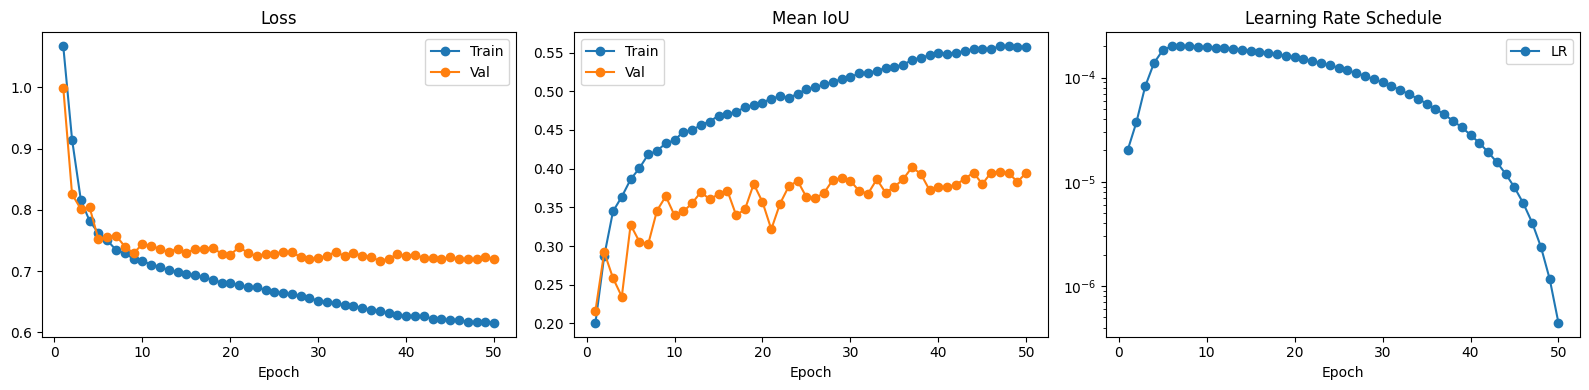

In [13]:
plot_train_history(history)

In [14]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES, siamese=True)

Test Loss: 1.2558
Test mIoU: 0.3091
Test Acc:  0.9131

Class                IoU     Prec   Recall
No Damage         0.9336   0.9698   0.9616
Minor             0.5632   0.6360   0.8310
Major             0.0204   0.1203   0.0239
Destroyed         0.0072   0.2326   0.0074
Unclassified      0.0212   0.0440   0.0394
